<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

# Load the dataset
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2100, 13)


,crop,temperature,rainfall,sunshine_hours,ph,organic_carbon,cec,awc,bulk_density,texture,texture_code,suitability,suitability_class
0,Brinjal,17.808959,1133.236278,8.516139,4.893566,2.858822,31.688154,0.011237,0.960308,sandy loam,3,0.788,Suitable
1,Brinjal,17.642692,2141.235609,3.981225,5.022755,1.616487,21.549202,0.021310,1.321414,clay loam,6,0.689,Unsuitable
2,Brinjal,23.250238,1056.557826,9.148416,7.987393,0.657953,39.543177,0.037554,1.267732,loamy sand,2,0.781,Suitable
3,Brinjal,32.147649,1519.315152,5.934370,6.986445,3.563073,18.646849,0.014938,1.472204,loamy sand,2,0.770,Suitable
4,Brinjal,18.858207,2410.624264,6.447417,5.834215,3.181929,21.797482,0.044940,1.295421,sand,1,0.623,Unsuitable


 2. Initial Inspection

In [ ]:
# Check column names and data types
df.info()

# Summary statistics for numeric columns
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop               2100 non-null   str    
 1   temperature        2100 non-null   float64
 2   rainfall           2100 non-null   float64
 3   sunshine_hours     2100 non-null   float64
 4   ph                 2100 non-null   float64
 5   organic_carbon     2100 non-null   float64
 6   cec                2100 non-null   float64
 7   awc                2100 non-null   float64
 8   bulk_density       2100 non-null   float64
 9   texture            2100 non-null   str    
 10  texture_code       2100 non-null   int64  
 11  suitability        2100 non-null   float64
 12  suitability_class  2100 non-null   str    
dtypes: float64(9), int64(1), str(3)
memory usage: 213.4 KB


crop                 0
temperature          0
rainfall             0
sunshine_hours       0
ph                   0
organic_carbon       0
cec                  0
awc                  0
bulk_density         0
texture              0
texture_code         0
suitability          0
suitability_class    0
dtype: int64

 3. Target Variable Analysis

suitability_class
Suitable      1335
Unsuitable     765
Name: count, dtype: int64


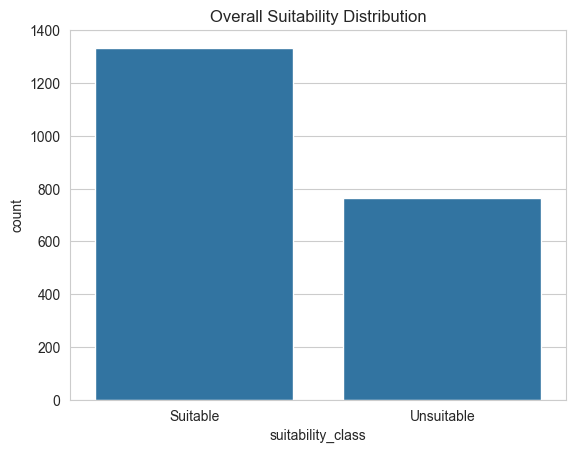

Number of crops: 21

Crops: <StringArray>
[       'Brinjal',          'Luffa',           'Okra',       'Cucumber',
    'Snake Gourd',   'Bitter Gourd',         'Radish',       'Capsicum',
 'Yard Long Bean',         'Banana',      'Pineapple',         'Ginger',
         'Papaya',  'Passion Fruit',   'Sweet Potato',       'Rambutan',
     'Mangosteen',         'Manioc',        'Kiriala',           'Yams',
       'Turmeric']
Length: 21, dtype: str


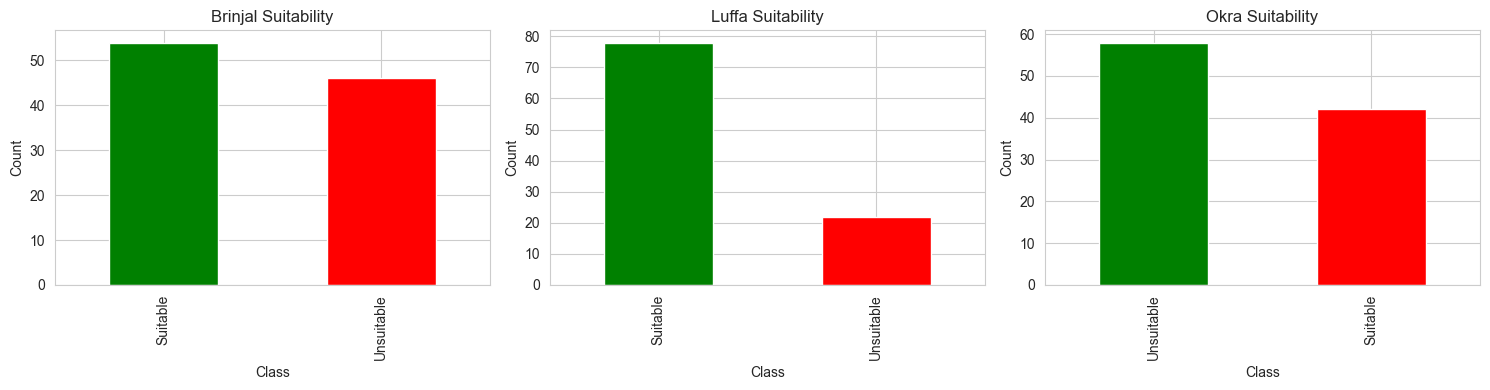

In [ ]:
# Distribution of suitability_class
print(df['suitability_class'].value_counts())
sns.countplot(x='suitability_class', data=df)
plt.title('Overall Suitability Distribution')
plt.show()

# Check per crop
crops = df['crop'].unique()
print("Number of crops:", len(crops))
print("\nCrops:", crops)

example_crops = ['Brinjal', 'Luffa', 'Okra']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, crop in zip(axes, example_crops):
    subset = df[df['crop'] == crop]
    subset['suitability_class'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title(f'{crop} Suitability')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

4. Distributions of Numeric Features

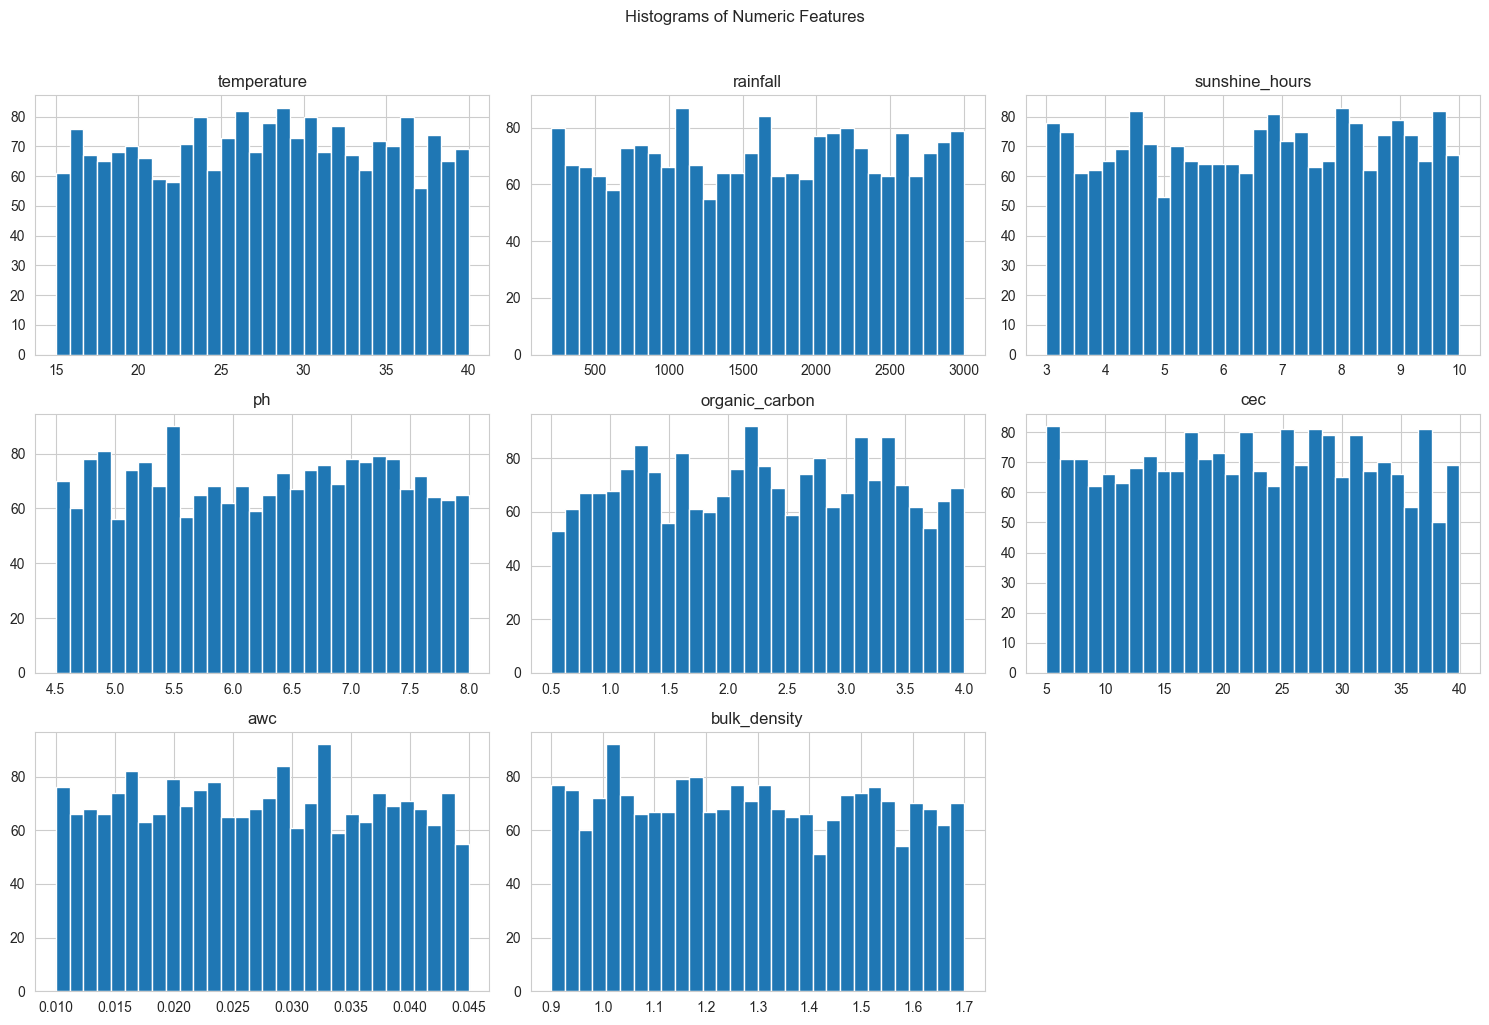

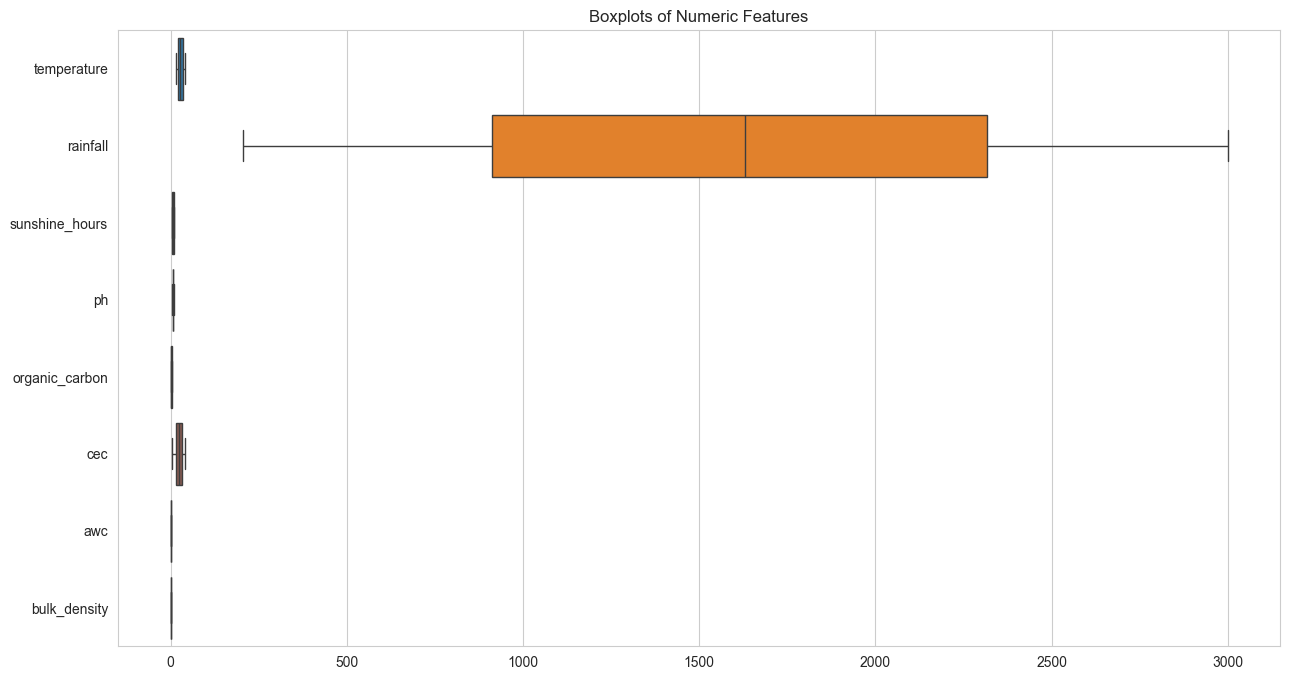

In [ ]:
# List of numeric features (excluding target, crop, texture name)
numeric_features = ['temperature', 'rainfall', 'sunshine_hours', 'ph',
                    'organic_carbon', 'cec', 'awc', 'bulk_density']

# Plot histograms
df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

# Boxplots to spot outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_features], orient='h')
plt.title('Boxplots of Numeric Features')
plt.show()

5. Categorical Features

Unique textures: <StringArray>
['sandy loam', 'clay loam', 'loamy sand', 'sand', 'loam', 'clay', 'silt loam']
Length: 7, dtype: str

Texture value counts:
texture
clay loam     321
clay          317
sand          311
sandy loam    304
silt loam     290
loamy sand    279
loam          278
Name: count, dtype: int64

Texture to code mapping:
       texture  texture_code
4         sand             1
2   loamy sand             2
0   sandy loam             3
5         loam             4
19   silt loam             5
1    clay loam             6
8         clay             7


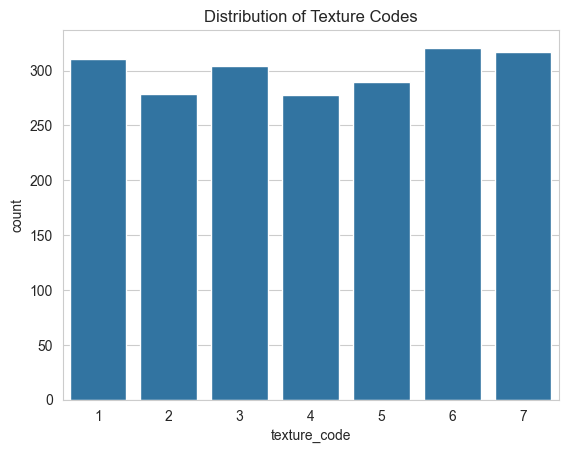

In [ ]:
# Texture and texture_code
print("Unique textures:", df['texture'].unique())
print("\nTexture value counts:")
print(df['texture'].value_counts())

# Relationship between texture and texture_code
texture_map = df[['texture', 'texture_code']].drop_duplicates().sort_values('texture_code')
print("\nTexture to code mapping:")
print(texture_map)

# Plot distribution of texture_code
sns.countplot(x='texture_code', data=df)
plt.title('Distribution of Texture Codes')
plt.show()

6. Relationships with Target Variable

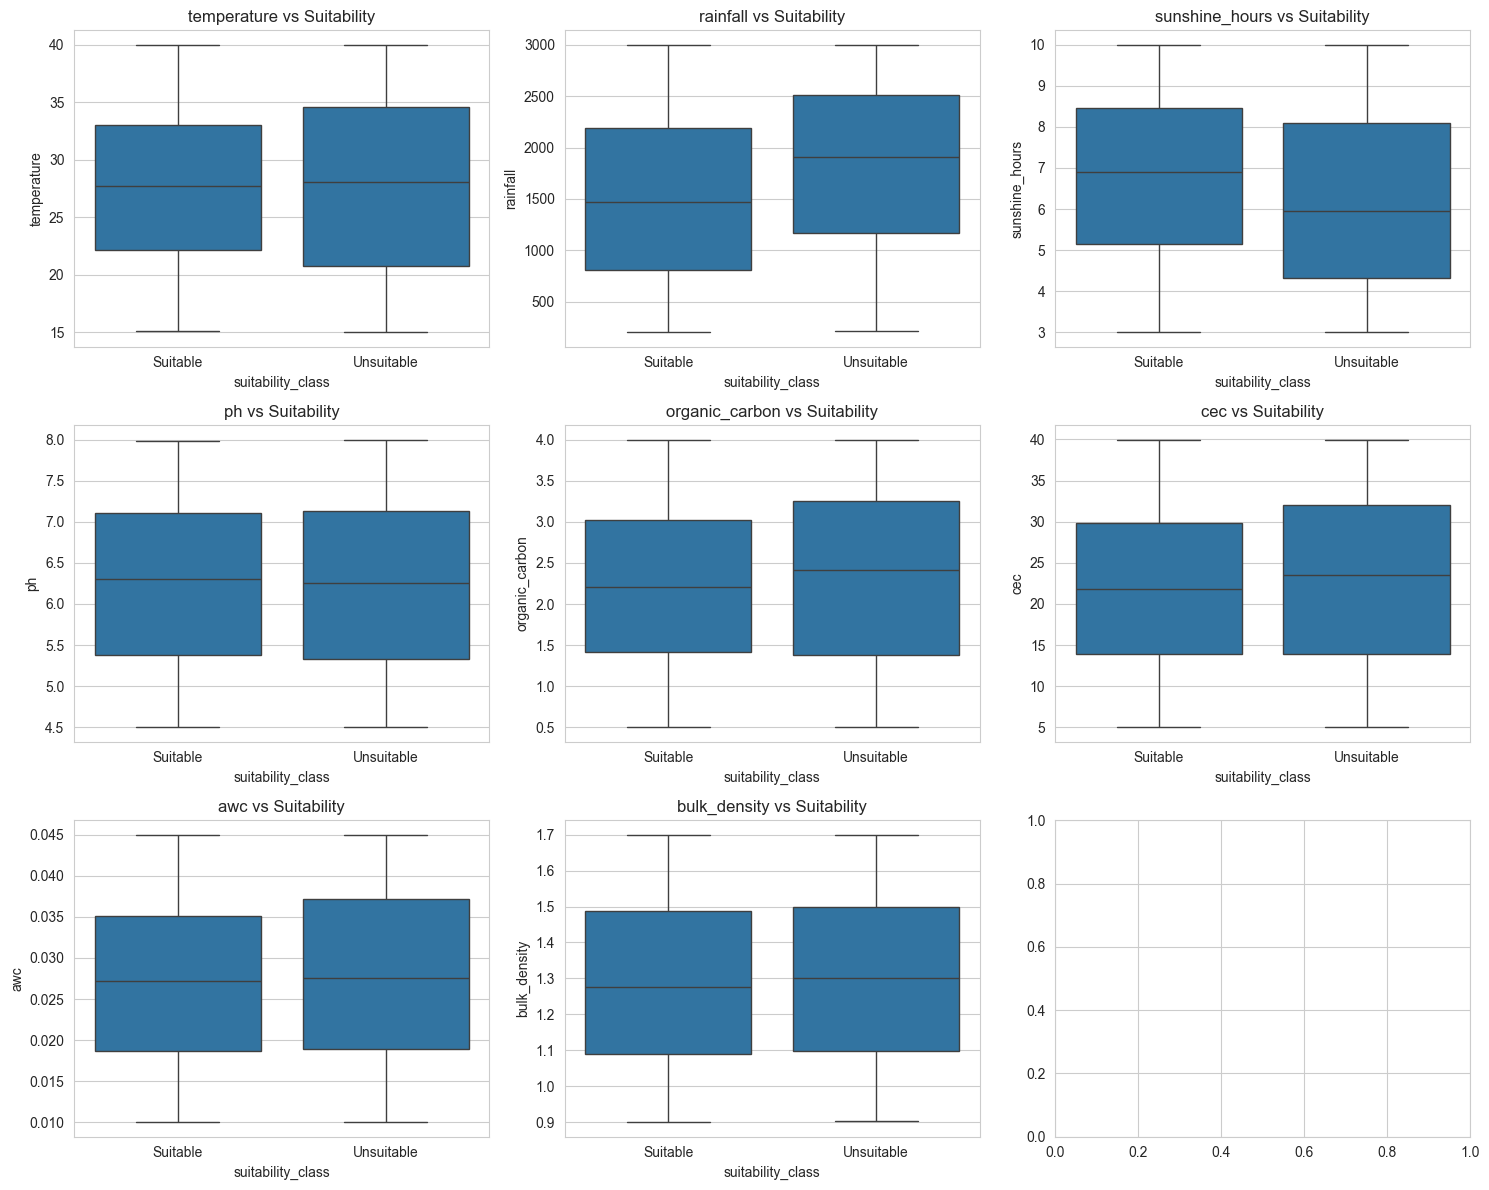

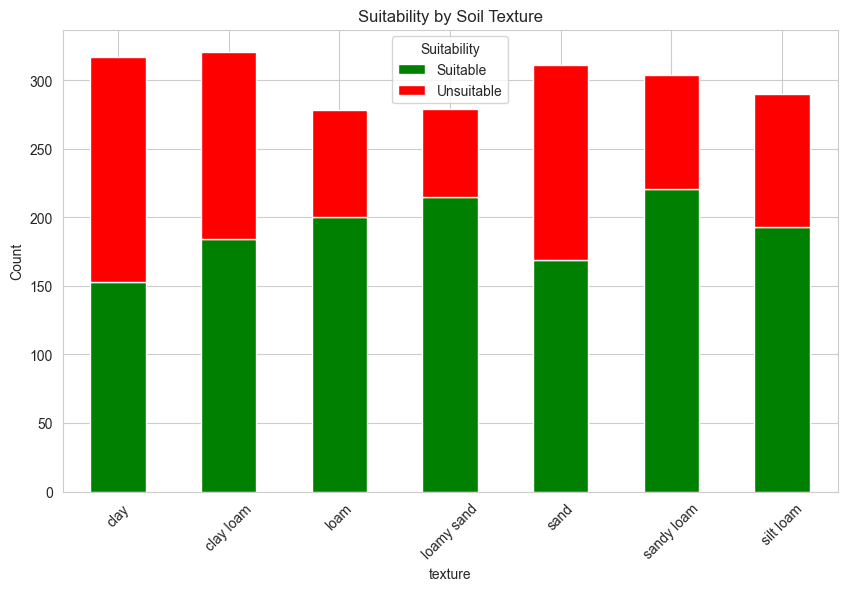

In [ ]:
# For each numeric feature, plot boxplots split by suitability
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='suitability_class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs Suitability')
plt.tight_layout()
plt.show()

# For texture, create a stacked bar chart
suit_by_texture = pd.crosstab(df['texture'], df['suitability_class'])
suit_by_texture.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'red'])
plt.title('Suitability by Soil Texture')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Suitability')
plt.show()

 7. Correlation Analysis

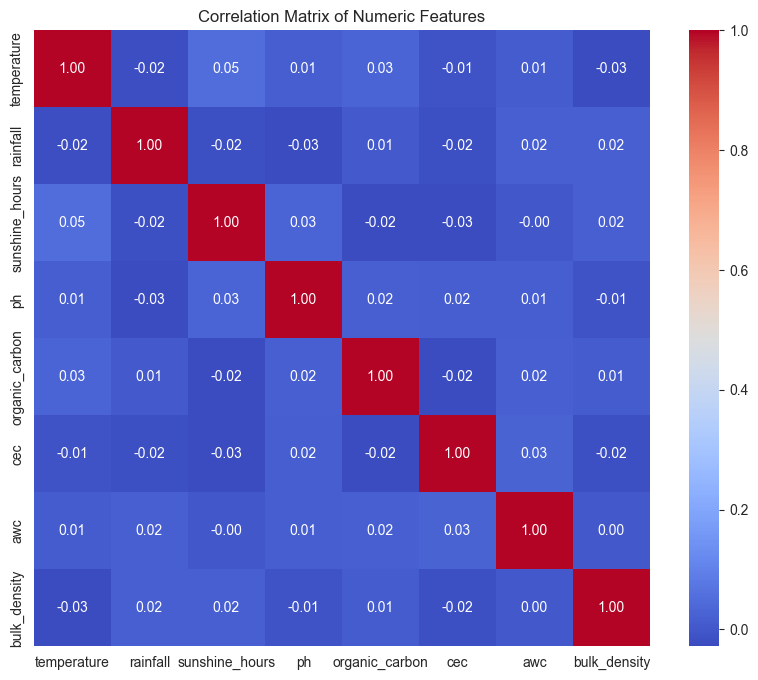

Correlation with target (point-biserial):
rainfall: -0.173
sunshine_hours: 0.135
organic_carbon: -0.060
cec: -0.043
awc: -0.030
bulk_density: -0.028
ph: 0.008
temperature: -0.001


In [ ]:
# Correlation matrix among numeric features
corr = df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Check correlations with target
from scipy.stats import pointbiserialr
target_binary = df['suitability_class'].map({'Suitable':1, 'Unsuitable':0})
corr_with_target = {}
for f in numeric_features:
    corr_with_target[f] = pointbiserialr(target_binary, df[f])[0]
print("Correlation with target (point-biserial):")
for k,v in sorted(corr_with_target.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{k}: {v:.3f}")